# use case - classifying Art Paintings as "Abstract" Vs "Landscape" using color features
## objective - Build an ml pipeline using SVM to classify painting into Abstract vs Landscape categories based only on dominant color distribution

Goal -show how SVM can sepearate non-traditional data(not text or tabular features, but color-based image features)

In [1]:
#1 . 
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
# 2
np.random.seed(42)

# abstract art = uses random, vibrant , scattered colors
abstract_colors = np.random.randint(50, 255, size=(30,3))

# lanscape = dominated by earthy/sky tone(green, brown, blue)
landscape_colors = np.random.randint(0,150, size=(30,3))

print(abstract_colors.shape)
print(landscape_colors.shape)

X = np.vstack([abstract_colors, landscape_colors])
y = np.array([0]*30 + [1]*30)
print(X.shape, y.shape)

(30, 3)
(30, 3)
(60, 3) (60,)


In [8]:
# 3 preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# 4. Dimensionality reduction for visulization

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

In [12]:
## 5.Train SVM Classifier

clf = svm.SVC(kernel = 'rbf', C=1, gamma= 0.5)
clf.fit(X_2d, y)

SVC(C=1, gamma=0.5)

In [13]:
# 5. visulaization
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
# predict decision function across grid
Z = clf.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

In [15]:
import matplotlib.pyplot as plt

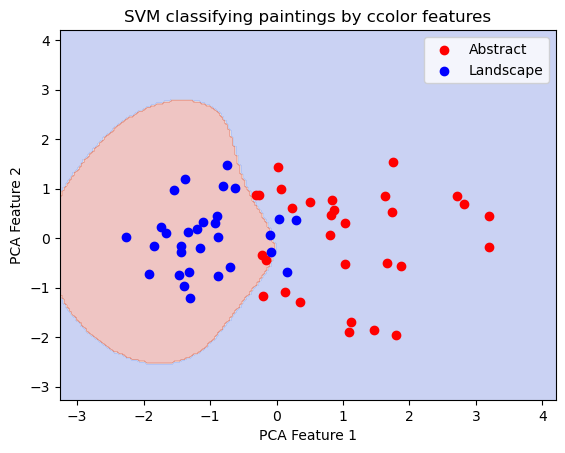

In [16]:
# 6 plotting
plt.contourf(xx, yy, Z, alpha =0.3, cmap= plt.cm.coolwarm)
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], color = 'red', label ="Abstract")
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], color = 'blue', label ="Landscape")

plt.title("SVM classifying paintings by ccolor features")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()
plt.show()
